# Cyclistic Bike-Share — Share Phase

Build the five visualizations for the executive-facing deliverable, using the small aggregate
tables produced in the Analyze phase (`data/summary/`). Palette: blue = members, orange = casual
riders, used consistently across every chart (categorical color assigned by identity, never by
rank or cycled).

## Setup

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import os

SUMMARY_DIR = "../data/summary"
IMG_DIR = "../images"
os.makedirs(IMG_DIR, exist_ok=True)

COLOR_MEMBER = "#2a78d6"
COLOR_CASUAL = "#eb6834"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "Segoe UI", "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 12,
})

def clean_axes(ax, hide_y=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(not hide_y)
    if hide_y:
        ax.yaxis.set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(length=0)
    ax.yaxis.grid(True, color=GRID, linewidth=1)
    ax.set_axisbelow(True)

## 1. Average ride length by rider type

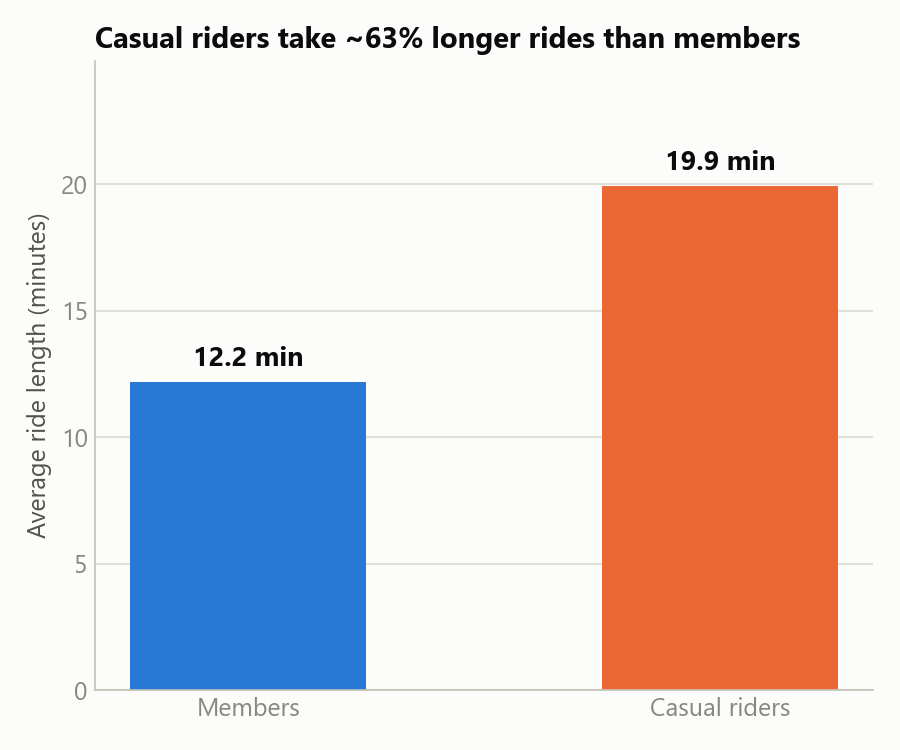

In [2]:
overall = pd.read_csv(os.path.join(SUMMARY_DIR, "overall_ride_length_stats.csv"))
overall = overall.set_index("member_casual").loc[["member", "casual"]]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Members", "Casual riders"], overall["mean"], width=0.5,
               color=[COLOR_MEMBER, COLOR_CASUAL])
for b, v in zip(bars, overall["mean"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.4, f"{v:.1f} min", ha="center", va="bottom",
             fontsize=13, color=INK_PRIMARY, fontweight="bold")
clean_axes(ax)
ax.set_ylabel("Average ride length (minutes)")
ax.set_title("Casual riders take ~63% longer rides than members", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
ax.set_ylim(0, overall["mean"].max() * 1.25)
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "01_avg_ride_length_by_type.png"), dpi=150)
plt.show()

## 2. Rides by day of week

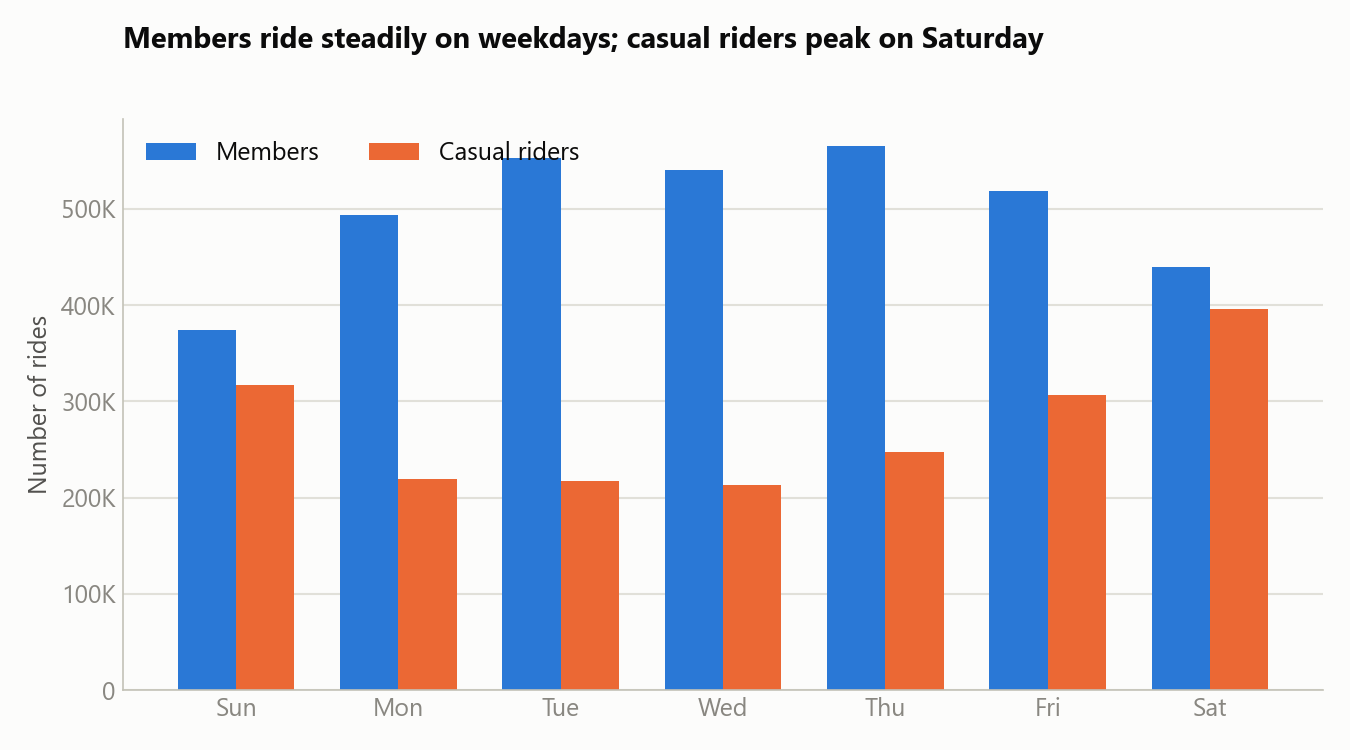

In [3]:
by_day = pd.read_csv(os.path.join(SUMMARY_DIR, "rides_by_day_of_week.csv"))
DAY_ORDER = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
DAY_ABBR = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]
piv = by_day.pivot(index="day_name", columns="member_casual", values="ride_count").loc[DAY_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(DAY_ORDER)); w = 0.36
ax.bar([i - w/2 for i in x], piv["member"], width=w, color=COLOR_MEMBER, label="Members")
ax.bar([i + w/2 for i in x], piv["casual"], width=w, color=COLOR_CASUAL, label="Casual riders")
ax.set_xticks(list(x)); ax.set_xticklabels(DAY_ABBR)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{int(v/1000)}K" if v else "0"))
clean_axes(ax)
ax.set_ylabel("Number of rides")
ax.set_title("Members ride steadily on weekdays; casual riders peak on Saturday", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left", pad=34)
ax.legend(frameon=False, loc="upper left", ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "02_rides_by_day_of_week.png"), dpi=150)
plt.show()

## 3. Rides by hour of day — the clearest commute vs. leisure signal

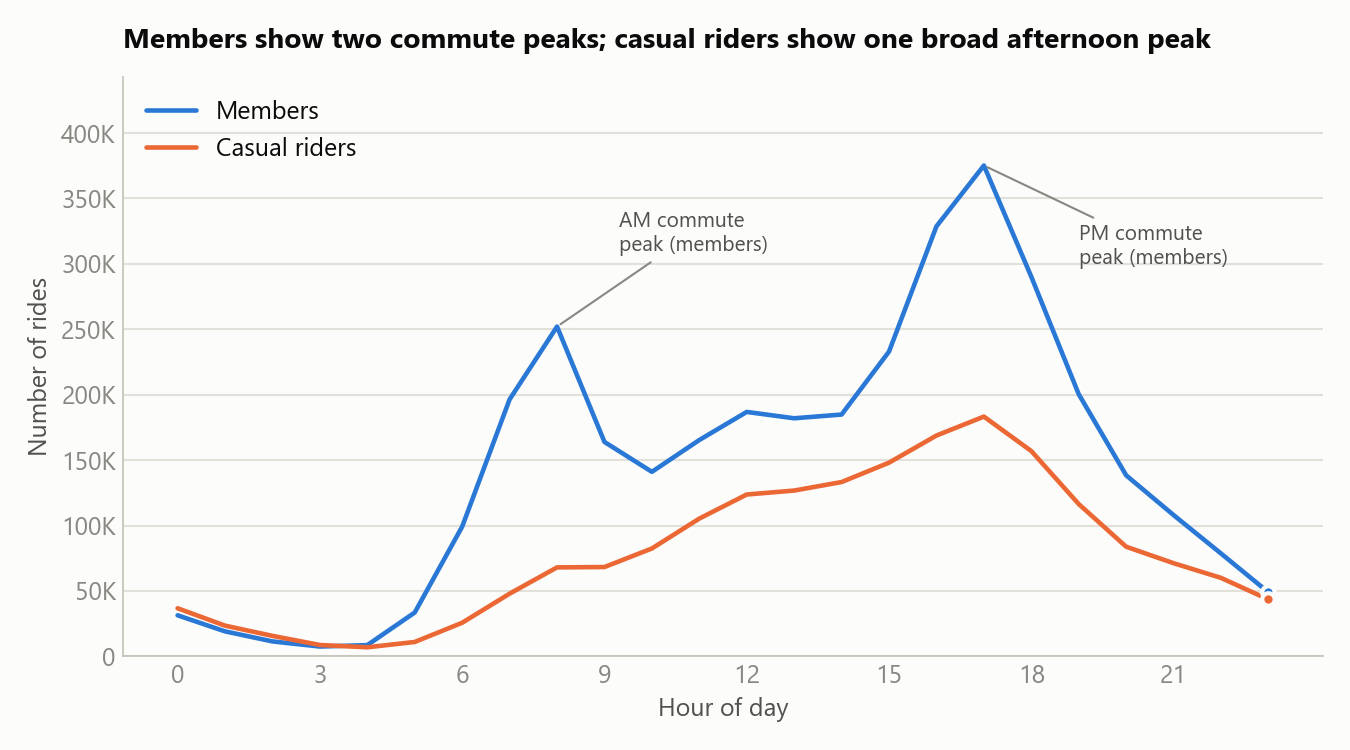

In [4]:
by_hour = pd.read_csv(os.path.join(SUMMARY_DIR, "rides_by_hour.csv"))
piv_h = by_hour.pivot(index="hour", columns="member_casual", values="ride_count")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(piv_h.index, piv_h["member"], color=COLOR_MEMBER, linewidth=2.2, solid_capstyle="round", label="Members")
ax.plot(piv_h.index, piv_h["casual"], color=COLOR_CASUAL, linewidth=2.2, solid_capstyle="round", label="Casual riders")
ax.scatter([piv_h.index[-1]], [piv_h["member"].iloc[-1]], s=36, color=COLOR_MEMBER, zorder=5, edgecolor=SURFACE, linewidth=2)
ax.scatter([piv_h.index[-1]], [piv_h["casual"].iloc[-1]], s=36, color=COLOR_CASUAL, zorder=5, edgecolor=SURFACE, linewidth=2)
ax.annotate("AM commute\npeak (members)", xy=(8, piv_h.loc[8, "member"]), xytext=(9.3, 310000),
            fontsize=10, color=INK_SECONDARY, arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=1))
ax.annotate("PM commute\npeak (members)", xy=(17, piv_h.loc[17, "member"]), xytext=(19, 300000),
            fontsize=10, color=INK_SECONDARY, arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=1))
ax.set_xticks(range(0, 24, 3)); ax.set_xlabel("Hour of day")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{int(v/1000)}K" if v else "0"))
clean_axes(ax)
ax.set_ylabel("Number of rides")
ax.set_ylim(0, piv_h["member"].max() * 1.18)
ax.set_title("Members show two commute peaks; casual riders show one broad afternoon peak",
              fontsize=13.5, color=INK_PRIMARY, fontweight="bold", loc="left", pad=14)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "03_rides_by_hour.png"), dpi=150)
plt.show()

## 4. Rides by month — seasonality

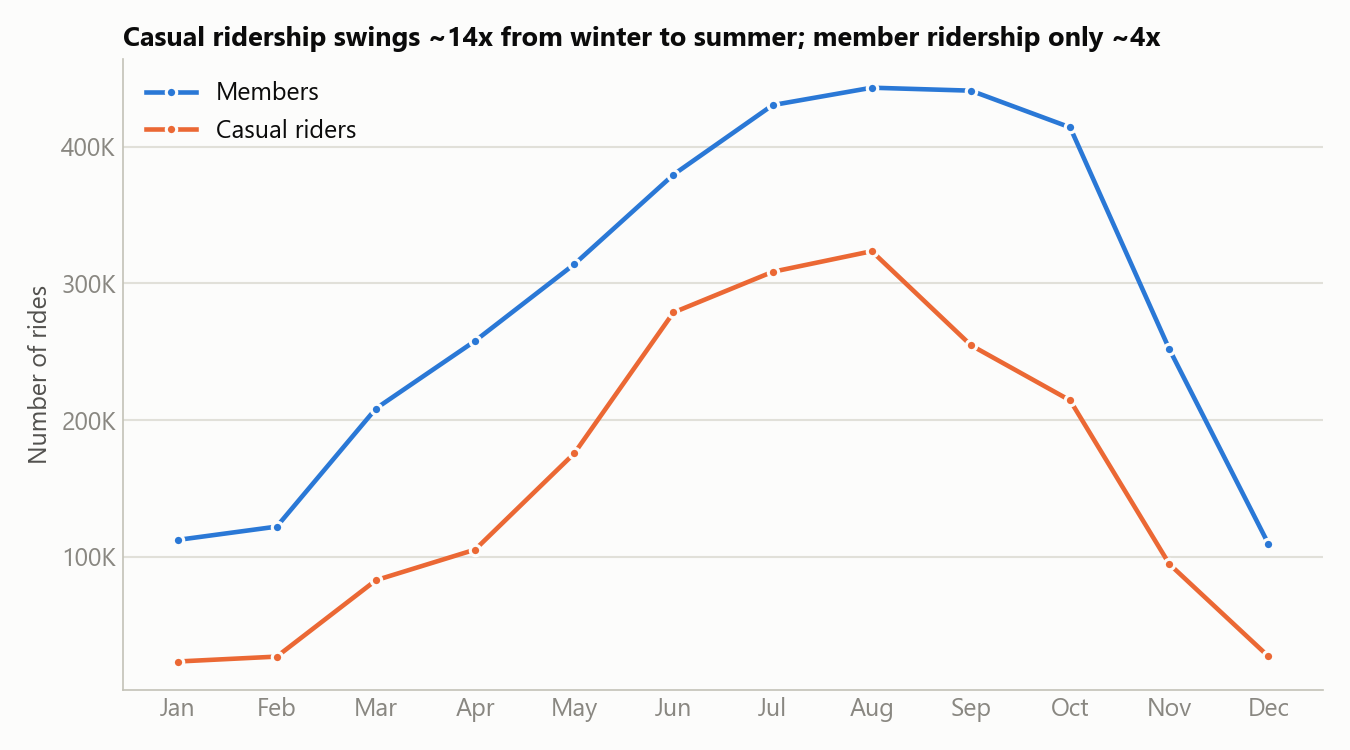

In [5]:
by_month = pd.read_csv(os.path.join(SUMMARY_DIR, "rides_by_month.csv"))
piv_m = by_month.pivot(index="month", columns="member_casual", values="ride_count")
MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(piv_m.index, piv_m["member"], color=COLOR_MEMBER, linewidth=2.2, marker="o", markersize=5,
        markerfacecolor=COLOR_MEMBER, markeredgecolor=SURFACE, markeredgewidth=1.5, label="Members")
ax.plot(piv_m.index, piv_m["casual"], color=COLOR_CASUAL, linewidth=2.2, marker="o", markersize=5,
        markerfacecolor=COLOR_CASUAL, markeredgecolor=SURFACE, markeredgewidth=1.5, label="Casual riders")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_ABBR)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{int(v/1000)}K" if v else "0"))
clean_axes(ax)
ax.set_ylabel("Number of rides")
ax.set_title("Casual ridership swings ~14x from winter to summer; member ridership only ~4x",
              fontsize=13, color=INK_PRIMARY, fontweight="bold", loc="left")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "04_rides_by_month.png"), dpi=150)
plt.show()

## 5. Weekday vs. weekend split

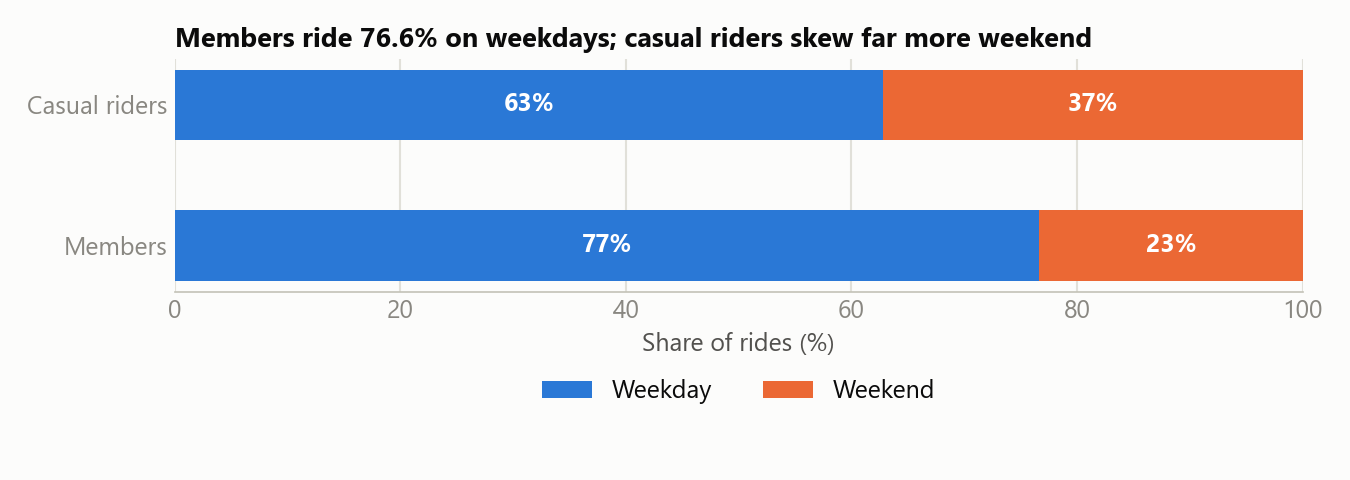

In [6]:
wk = pd.read_csv(os.path.join(SUMMARY_DIR, "weekday_vs_weekend.csv"))
wk = wk.set_index("member_casual").loc[["member", "casual"]]
wk_pct = wk.div(wk.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 3.2))
labels = ["Members", "Casual riders"]; y = range(len(labels))
ax.barh(y, wk_pct["weekday"], color=COLOR_MEMBER, height=0.5, label="Weekday")
ax.barh(y, wk_pct["weekend"], left=wk_pct["weekday"], color=COLOR_CASUAL, height=0.5, label="Weekend")
for i, (wd, we) in enumerate(zip(wk_pct["weekday"], wk_pct["weekend"])):
    ax.text(wd/2, i, f"{wd:.0f}%", ha="center", va="center", color="white", fontsize=12, fontweight="bold")
    ax.text(wd + we/2, i, f"{we:.0f}%", ha="center", va="center", color="white", fontsize=12, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(labels)
ax.set_xlim(0, 100); ax.set_xlabel("Share of rides (%)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(BASELINE); ax.tick_params(length=0)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)
ax.set_title("Members ride 76.6% on weekdays; casual riders skew far more weekend",
              fontsize=13, color=INK_PRIMARY, fontweight="bold", loc="left")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "05_weekday_vs_weekend.png"), dpi=150)
plt.show()

## Summary

Every chart points the same direction: **members use Cyclistic to commute, casual riders use it
for leisure.** See [`docs/05_share.md`](../docs/05_share.md) for the full write-up.